# Model A vs Baseline SNR Comparison

This notebook compares the SNR results of Model A with the original baseline using the merged CSV file with a clear SNR column. It provides summary statistics and visualizations for a fair, direct comparison.

## 1. Import Required Libraries
Import pandas, numpy, matplotlib, and seaborn for data analysis and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde


sns.set_theme(style="whitegrid")

## 2. Load Model A and Baseline Results
Load Model A results and the merged baseline CSV, ensuring both have a clear SNR column.

In [3]:
# File paths (update if needed)
model_a_path = '../data/logs/e2e/test/2JB0ZX/lightning_logs/version_0/metrics.csv'
baseline_path = '../third_party/query-bandit/reproducibility/results/query/bandit_ev_merged.csv'

# Load CSVs
df_model_a = pd.read_csv(model_a_path)
df_baseline = pd.read_csv(baseline_path)

# Select the correct SNR columns for comparison
# For Model A, use SafeSignalNoiseRatio (standard SNR)
snr_col_a = 'test/target/snr/SafeSignalNoiseRatio'
# For baseline, use the column named 'snr' (or update if different)
snr_col_b = 'snr' if 'snr' in df_baseline.columns else df_baseline.columns[0]

print(f"Model A SNR column: {snr_col_a}")
print(f"Baseline SNR column: {snr_col_b}")

Model A SNR column: test/target/snr/SafeSignalNoiseRatio
Baseline SNR column: snr


## 3. Clean and Prepare SNR Data
Drop NaN/infinite values and align SNR columns for fair comparison.

In [4]:
# Clean SNR columns
df_model_a_clean = df_model_a.copy()
df_baseline_clean = df_baseline.copy()

if snr_col_a:
    df_model_a_clean = df_model_a_clean[df_model_a_clean[snr_col_a].replace([np.inf, -np.inf], np.nan).notna()]
if snr_col_b:
    df_baseline_clean = df_baseline_clean[df_baseline_clean[snr_col_b].replace([np.inf, -np.inf], np.nan).notna()]

print(f"Model A valid SNR count: {len(df_model_a_clean)}")
print(f"Baseline valid SNR count: {len(df_baseline_clean)}")

Model A valid SNR count: 200
Baseline valid SNR count: 2000


## 4. Compare SNR Distributions
Show summary statistics and visualize SNR distributions for Model A and the baseline.

In [5]:
# Summary statistics
snr_a = df_model_a_clean[snr_col_a] if snr_col_a else pd.Series([])
snr_b = df_baseline_clean[snr_col_b] if snr_col_b else pd.Series([])

summary_df = pd.DataFrame({
    'Model_A': snr_a.reset_index(drop=True),
    'Baseline': snr_b.reset_index(drop=True)
})
display(summary_df.describe())

,Model_A,Baseline
count,200.000000,2000.000000
mean,0.048985,5.599953
std,0.086491,4.981348
min,0.000303,-13.789231
25%,0.002461,0.767559
50%,0.006513,6.162158
75%,0.075298,9.505413
max,0.441040,18.090504


In [6]:
snr_cols = [col for col in df_model_a.columns if 'snr' in col.lower() or 'SNR' in col]
print("SNR-related columns found:")
for col in snr_cols:
    vals = df_model_a[col].dropna()
    print(f"  {col}: {len(vals)} values, mean={vals.mean():.3f}, min={vals.min():.3f}, max={vals.max():.3f}")

SNR-related columns found:
  test/target/snr/PredictedDecibels: 200 values, mean=-113.756, min=-120.000, max=-76.935
  test/target/snr/SafeScaleInvariantSignalNoiseRatio: 200 values, mean=0.049, min=0.000, max=0.441
  test/target/snr/SafeSignalNoiseRatio: 200 values, mean=0.049, min=0.000, max=0.441
  test/target/snr/TargetDecibels: 200 values, mean=-43.528, min=-60.428, max=-28.896


In [7]:
snr_a = df_model_a[snr_col_a].dropna()
print(f"Count: {len(snr_a)}")
print(f"Unique values: {snr_a.nunique()}")
print(f"Value counts (top 10):\n{snr_a.value_counts().head(10)}")
print(f"\nFirst 20 raw values:\n{snr_a.values[:20]}")

Count: 200
Unique values: 198
Value counts (top 10):
test/target/snr/SafeSignalNoiseRatio
0.003581    2
0.000520    2
0.009088    1
0.000303    1
0.101352    1
0.294384    1
0.245480    1
0.006480    1
0.000480    1
0.000372    1
Name: count, dtype: int64

First 20 raw values:
[0.00908837 0.00030337 0.10135227 0.29438424 0.24547993 0.0064796
 0.00048042 0.00037222 0.00228254 0.0064889  0.00044884 0.09076864
 0.11403279 0.00052649 0.00053063 0.00728183 0.12856162 0.01313227
 0.01905783 0.01370103]


In [8]:
print(f"Baseline columns: {df_baseline.columns.tolist()}")
snr_b = df_baseline[snr_col_b].dropna()
print(f"\nCount: {len(snr_b)}")
print(f"Mean: {snr_b.mean():.3f}, Std: {snr_b.std():.3f}")
print(f"Min: {snr_b.min():.3f}, Max: {snr_b.max():.3f}")

Baseline columns: ['song', 'stem', 'snr', 'variant', 'inference_mode']

Count: 2000
Mean: 5.600, Std: 4.981
Min: -13.789, Max: 18.091


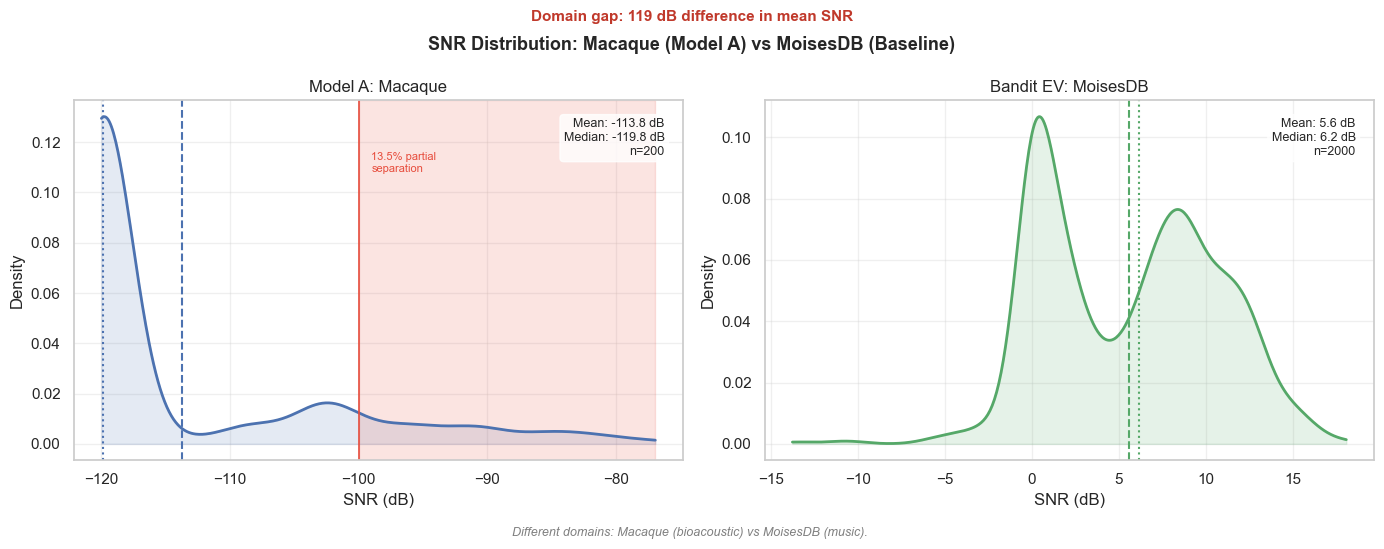

Model A (Macaque): mean=-113.76 dB, median=-119.84 dB, std=10.79 dB, n=200
Baseline (MoisesDB): mean=5.60 dB, median=6.16 dB, std=4.98 dB, n=2000


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SNR Distribution: Macaque (Model A) vs MoisesDB (Baseline)',
             fontsize=13, fontweight='bold')

datasets = [
    (snr_a, 'Model A: Macaque',    '#4C72B0', axes[0]),
    (snr_b, 'Bandit EV: MoisesDB', '#55A868', axes[1]),
]

for data, label, color, ax in datasets:
    kde = gaussian_kde(data, bw_method=0.2)
    x = np.linspace(data.min(), data.max(), 500)
    ax.plot(x, kde(x), color=color, linewidth=2)
    ax.fill_between(x, kde(x), alpha=0.15, color=color)
    ax.axvline(data.mean(),   color=color, linestyle='--', linewidth=1.5)
    ax.axvline(data.median(), color=color, linestyle=':',  linewidth=1.5)
    ax.set_xlabel('SNR (dB)')
    ax.set_ylabel('Density')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    # Clean stats box instead of legend
    ax.text(0.97, 0.95,
            f'Mean: {data.mean():.1f} dB\nMedian: {data.median():.1f} dB\nn={len(data)}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# ✅ Partial separation annotation — explicitly on axes[0] (Macaque)
ax_mac = axes[0]
ax_mac.axvspan(-100, snr_a.max(), alpha=0.15, color='#E74C3C')
ax_mac.axvline(-100, color='#E74C3C', linestyle='-', linewidth=1.2)
ax_mac.text(-99, ax_mac.get_ylim()[1] * 0.85,
            '13.5% partial\nseparation',
            fontsize=8, color='#E74C3C', va='top')

# Domain gap headline
fig.text(0.5, 1.01,
         f'Domain gap: {snr_b.mean() - snr_a.mean():.0f} dB difference in mean SNR',
         ha='center', fontsize=11, fontweight='bold', color='#C0392B')

# Footnote
fig.text(0.5, -0.02,
         'Different domains: Macaque (bioacoustic) vs MoisesDB (music). ',
         ha='center', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.show()

for data, label in [(snr_a, 'Model A (Macaque)'), (snr_b, 'Baseline (MoisesDB)')]:
    print(f"{label}: mean={data.mean():.2f} dB, median={data.median():.2f} dB, "
          f"std={data.std():.2f} dB, n={len(data)}")

In [10]:
above_threshold = (snr_a > -100).sum()
print(f"Samples with SNR > -100 dB: {above_threshold} ({100*above_threshold/len(snr_a):.1f}%)")

Samples with SNR > -100 dB: 27 (13.5%)
